In [91]:
'''Data import'''
from pathlib import Path

'''Dataframes'''
import pandas as pd

'''Boxplots'''
import matplotlib.pyplot as plt

'''Split Dataset for testing'''
from sklearn.model_selection import train_test_split

'''Pipeline and model class'''
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

'''For tansforming "PULocationID", "DOLocationID" to binary values'''
from sklearn.preprocessing import OneHotEncoder

'''For transforming "PULocationID", "DOLocationID" without chaning the trip distance (just parsing)'''
from sklearn.compose import ColumnTransformer

'''For calculation RSME'''
from sklearn.metrics import root_mean_squared_error

'''For creating arrays'''
import numpy as np

'''Administring and documenting results of trained models'''
import mlflow

'''For Hyperparameter-tuning of the model'''
from sklearn.model_selection import GridSearchCV

In [19]:
'''Load cleaned parquet file in data frame'''
cleaned_dir = Path("./data/cleaned/")
cleaned_name = cleaned_dir / "cleaned_yellow_tripdata_2025_01.parquet"
df_clean = pd.read_parquet(cleaned_name)

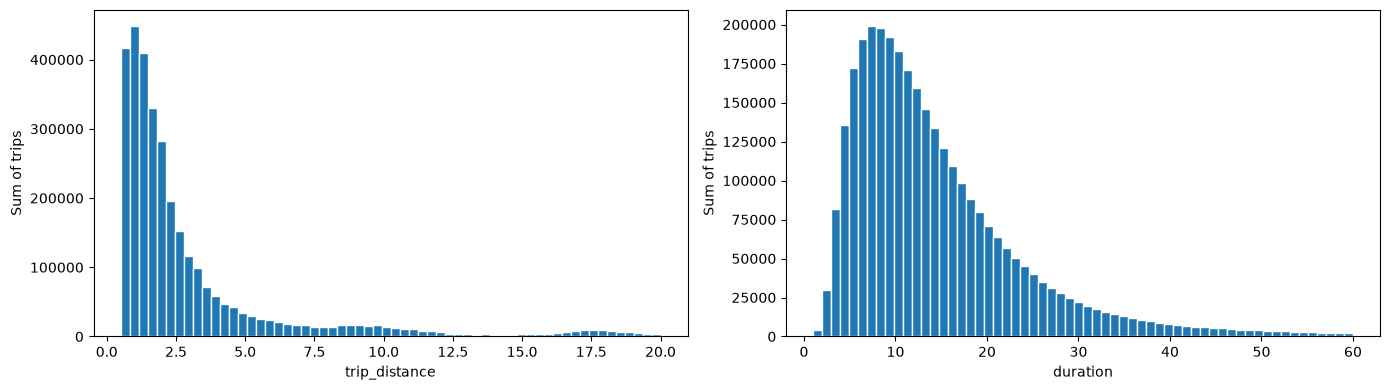

In [20]:
'''Check if correct and cleaned Dataframe was loaded'''
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, column in zip(axes, ["trip_distance", "duration"]):
    ax.hist(df_clean[column], bins=60, edgecolor="white")
    ax.set_xlabel(column)
    ax.set_ylabel("Sum of trips")

plt.tight_layout()
plt.show()

In [ ]:
'''Setting up test sets'''
features = ["PULocationID", "DOLocationID", "trip_distance", "duration"]

X = df_clean[features].drop(columns="duration").copy()
y = df_clean["duration"].copy()

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

In [ ]:
'''Check of data split fits to each other'''
if len(X_train) == len(y_train):
    print(f"Rows of X_train ({len(X_train)}) and y_train ({len(y_train)}) matching exactly.")

else:
    print(f"X_train: {len(X_train)} doesn't match y_train: {len(y_train)}")

if len(X_val) == len(y_val):
    print(f"Rows of X_val ({len(X_val)}) and y_val ({len(y_val)}) matching exactly.")

else:
    print(f"X_val: {len(X_val)} doesn't match y_val: {len(y_val)}")


Rows of X_train (2539717) and y_train (2539717) matching exactly.
Rows of X_val (634930) and y_val (634930) matching exactly.


Vor dem Training müssen noch die Gebiets-IDs berücksichtigt werden.  \
Sie sind Kategorien, keine Messwerte → **Dafür können wir One-Hot-Encoding verwenden**  \
Jedes Gebiet bekommt dabei eine eigene Ja/Nein-Spalte.  \
Die Strecke bleibt eine numerische Eingabe.

Ein Random Forest würde numerische IDs beispielsweise über Regeln wie Gebiets-ID ≤ 150 aufteilen.  \
Damit würde er Gebiete anhand ihrer Nummer gruppieren.  \
One-Hot-Encoding ermöglicht stattdessen die Unterscheidung nach einzelnen Gebieten, ohne eine Reihenfolge vorzugeben.

Die ursprüngliche Spalte mit den IDs wird durch One-Hot-Encoding in neuen Spalten ersetzt. Die Strecke bleibt unverändert.  \
Das Modell bekommt dadurch Informationen wie „Startet die Fahrt in Gebiet 200?“ → **Es muss die Zahl 200 aber nicht als Messwert behandeln**

Beispiel:
| Fahrt | Startgebiet_100 | Startgebiet_200 | Strecke |
|---|---:|---:|---:|
| A | 1 | 0 | 3,5 |
| B | 0 | 1 | 2,0 |
| C | 1 | 0 | 7,0 |



| Bestandteil | Aufgabe |
|---|---|
| `OneHotEncoder` | Gebiets-IDs in Ja/Nein-Spalten umwandeln |
| `ColumnTransformer` | Encoding nur auf die Gebietsspalten anwenden und die Strecke unverändert durchreichen |
| `RandomForestRegressor` | Fahrtdauer vorhersagen |

`handle_unknown="ignore"` → Damit bricht die Verarbeitung nicht ab, wenn später ein Gebiet auftaucht, das im Training fehlte. Für dieses Gebiet bleiben die zugehörigen One-Hot-Spalten dann alle 0.

`remainder="passthrough"` → Alle nicht ausdrücklich ausgewählten Spalten werden unverändert weitergegeben.

In [54]:
'''Defining the pipeline'''
categorical_features = ["PULocationID", "DOLocationID"]

preprocessor = ColumnTransformer(
    transformers = [
        ("locations", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

In [ ]:
'''Test behaviour of pipeline with small dataset of 50.000 rows from ny taxi'''

X_train_small = X_train.sample(n=50_000, random_state=42)

y_train_small = y_train.loc[X_train_small.index]

In [56]:
pipeline.fit(X_train_small, y_train_small)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](3,)","['PULocationID','DOLocationID','trip_distance']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,3
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('locations', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of

In [ ]:
y_pred = pipeline.predict(X_val)

rmse = root_mean_squared_error(y_val, y_pred)

print(f"RMSE: {rmse:.3f} minutes")

RMSE: 5.062 Minuten


**RMSE:** Bei jeder Fahrt wird die Differenz zwischen vorhergesagter und tatsächlicher Fahrtdauer berechnet.  \
Diese Fehler werden quadriert, gemittelt und anschließend wird die Quadratwurzel gezogen.
Große Fehler fallen dadurch stärker ins Gewicht.

>RMSE = 0 → Alle Vorhersagen stimmen exakt

Jetzt folgt die Prüfung, ob dieser Wert akzeptabel oder schlecht ist

In [ ]:
'''Calculating mean of y_train'''
baseline_duration = y_train_small.mean()
print(baseline_duration)

14.474941000000001


In [74]:
'''
Create array y_pred_baseline with same length of y_val
Fill it with mean of y_train_small → 14.47...
Calculate the RMSE as rmse_baseline
'''
y_pred_baseline = np.full(len(y_val), baseline_duration)

rmse_baseline = root_mean_squared_error(y_val, y_pred_baseline)

if rmse_baseline > rmse:
    print(f"RMSE Baseline {rmse_baseline:.3f} is worse than RMSE {rmse: .3f}")
elif rmse_baseline == rmse:
    print(f"RMSE Baseline {rmse_baseline:.3f} is identical to RMSE {rmse: .3f}")
else:
    print(f"RMSE Baseline {rmse_baseline:.3f} is better than RMSE {rmse: .3f}")

RMSE Baseline 9.422 is worse than RMSE  5.062


In [77]:
mlflow.set_tracking_uri("sqlite:///../mlflow.db")
mlflow.set_experiment("ny_taxi_duration")

2026/09/30 11:53:57 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/30 11:53:57 INFO mlflow.store.db.utils: Updating database tables
2026/09/30 11:53:59 INFO mlflow.tracking.fluent: Experiment with name 'ny_taxi_duration' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:c:/Users/moma0/Documents/Weiterbildung/00_GitHub_Repo/Modul3/mle-model-deployment-project/notebooks/mlruns/1', creation_time=1790762039265, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1790762039265, lifecycle_stage='active', name='ny_taxi_duration', tags={}, trace_location=None, workspace='default'>

In [85]:
with mlflow.start_run(run_name="random-forest-50_000"):
    mlflow.log_params({"training_rows": len(X_train_small), "random_state": 42})
    mlflow.log_metrics({"rmse_validation": rmse, "rmse_baseline": rmse_baseline})
    model_info = mlflow.sklearn.log_model(
        sk_model=pipeline,
        name="ny_taxi_pipeline",
        input_example=X_train_small.head(5),
        skops_trusted_types=["sklearn.tree._tree.Tree"]
    )

c:\Users\moma0\Documents\Weiterbildung\00_GitHub_Repo\Modul3\mle-model-deployment-project\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/09/30 12:21:11 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifie

Als nächstes prüfen, ob die lokale pipeline und die in MLflow gespeicherte pipeline die selben Ergebnisse liefert:

In [ ]:
'''Eindeutiger MLflow-Verweis auf die gespeicherte Pipeline'''
print(model_info.model_uri)

models:/m-22e17d92ca41423296b4ceb98ca64c04


In [ ]:
'''Loading the pipeline from MLflow'''
loaded_pipeline = mlflow.sklearn.load_model(model_info.model_uri)

In [90]:
X_val_check = X_val.head(5)

check1 = pipeline.predict(X_val_check)
check2 = loaded_pipeline.predict(X_val_check)

'''Both outputs have to be the same'''
print (check1, check2)
'''Or check it this way'''
print(np.allclose(check1, check2))

[29.98255556 27.70566667  5.24160278 11.48908333 10.22936667] [29.98255556 27.70566667  5.24160278 11.48908333 10.22936667]
True


# Next: Hyperparamter-Tuning
Ein Random Forest besteht aus vielen Entscheidungsbäumen.  \
Jeder Baum stellt nacheinander Fragen zu einer Fahrt, etwa „Ist die Strecke länger als 3?“ oder „Startet sie in Gebiet 229?“.  \
Am Ende landet die Fahrt in einem Blatt, das eine Fahrtdauer vorhersagt.

`max_depth`: Wie viele Entscheidungsebenen darf ein Baum haben?
- Geringe Tiefe: wenige Fragen, grobe Unterscheidungen. Wichtige Zusammenhänge könnten übersehen werden
- Große Tiefe: feinere Unterscheidungen. Der Baum könnte auch zufällige Besonderheiten der Trainingsdaten lernen – das nennt man **Overfitting**

`min_samples_leaf`: Wie viele Trainingsbeispiele müssen mindestens in einem Blatt liegen?
Bei einem üblichen Regressionsbaum beruht die Vorhersage eines Blatts auf dem Mittelwert der dort angekommenen Trainingszielwerte.
- 1: Ein Blatt darf auf einer einzigen Trainingsfahrt beruhen. Das ermöglicht sehr spezielle Regeln.
- 20: Jedes Blatt muss mindestens 20 Trainingsbeispiele enthalten. Das verhindert Regeln für einzelne Sonderfälle und kann Vorhersagen stabiler machen.
Beide Parameter steuern also, wie fein das Modell unterscheiden darf. Zu grob kann ungenau sein; zu fein kann auf neuen Daten schlecht funktionieren. Welche Einstellung passt, prüft man mittels **Cross-Validation**.

In [93]:
'''Defining tuning'''
tuning_params = {
    "model__max_depth": [10, 20, None],
    "model__min_samples_leaf": [1, 5, 20]
}

search = GridSearchCV(
    estimator=loaded_pipeline,
    param_grid=tuning_params,
    scoring="neg_root_mean_squared_error",
    cv=3
)

'''Train with tuning variables'''
search.fit(X_train_small, y_train_small)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [10, 20, ...], 'model__min_samples_leaf': [1, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, defau

- `estimator`: die Pipeline, deren Modelleinstellungen wir vergleichen.
- `param_grid`: die zu prüfenden Hyperparameterwerte.
- `cv=3`: Die Trainingsstichprobe wird in drei Teile aufgeteilt. Jede Einstellung wird dreimal trainiert und jeweils auf dem zurückgehaltenen Teil bewertet.
- `scoring="neg_root_mean_squared_error"`: bewertet nach RMSE, allerdings mit negativem Vorzeichen. Scikit-learn bevorzugt größere Scores: −5 ist besser als −9, entsprechend einem kleineren RMSE.
Das ergibt 27 Trainingsläufe, anschließend wird die beste Kombination auf der gesamten übergebenen Trainingsstichprobe trainiert.

In [ ]:
'''Output best param combination'''
print(search.best_params_)
print("RMSE:", -search.best_score_)

{'model__max_depth': 20, 'model__min_samples_leaf': 5}
RMSE: 4.944295006983592


Best combination:  \
`model__max_depth` → 20  \
`model__min_samples_leaf` → 5

Next step: predicting original set of X_val, y_val with tuned model

In [ ]:
y_pred_tuned = search.predict(X_val)

rmse_tuned = root_mean_squared_error(y_val, y_pred_tuned)

print(f"RMSE tuned: {rmse_tuned:.3f} minutes")
print(f"RMSE from first trained pipeline: {rmse: .3f} minutes")

RMSE tuned: 4.882 minutes
RMSE from first trained pipeline:  5.062 minutes


In [103]:
'''Now saving tuned model in mlflow'''
with mlflow.start_run(run_name="random-forest-50_000_tuned"):
    mlflow.log_params({"training_rows": len(X_train_small), "random_state": 42})
    mlflow.log_params(search.best_params_)
    mlflow.log_metrics({"rmse_validation": rmse_tuned,"rmse_cv":-search.best_score_ ,"rmse_original": rmse})
    tuned_model_info = mlflow.sklearn.log_model(
        sk_model=search.best_estimator_,    #tuned pipeline with best parameters
        name="ny_taxi_pipeline",
        input_example=X_train_small.head(5),
        skops_trusted_types=["sklearn.tree._tree.Tree"]
    )

c:\Users\moma0\Documents\Weiterbildung\00_GitHub_Repo\Modul3\mle-model-deployment-project\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/09/30 15:13:25 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifie

In [104]:
'''Eindeutiger MLflow-Verweis auf die gespeicherte Pipeline'''
print(tuned_model_info.model_uri)

models:/m-6b5e098d04194514bd50bd67632dfa7c


In [105]:
'''Loading the tuned pipeline from MLflow'''
loaded_tuned_pipeline = mlflow.sklearn.load_model(tuned_model_info.model_uri)

In [110]:
'''Checking, if local tuned pipeline and tuned mlflow pipeline have the same results'''
#Reusing X_val_check from above
X_val_check = X_val.head(5)

check3 = search.best_estimator_.predict(X_val_check)
check4 = loaded_tuned_pipeline.predict(X_val_check)

'''Both outputs have to be the same'''
print (check3, check4)
'''Or check it this way'''
print(np.allclose(check3, check4))

[30.45556407 23.54955411  5.14179102 13.5957926  11.57462079] [30.45556407 23.54955411  5.14179102 13.5957926  11.57462079]
True


# Next step is refactoring the notebooks to executable code
→ See file 'pipeline.py'